## 1. Loading Dataset

In [1]:
# !pip install imageio matplotlib numpy scipy

In [2]:
import os

os.environ['KAGGLE_API_TOKEN']= 'KGAT_bca99b424890c3d02657ecf09376f40d'

In [3]:
! kaggle datasets download -d lokeshsaipureddi/drishtigs-retina-dataset-for-onh-segmentation

Dataset URL: https://www.kaggle.com/datasets/lokeshsaipureddi/drishtigs-retina-dataset-for-onh-segmentation
License(s): CC0-1.0
100% 341M/341M [00:10<00:00, 32.9MB/s]



In [4]:
! unzip drishtigs-retina-dataset-for-onh-segmentation.zip -d dataset_onh_segmentation

Archive:  drishtigs-retina-dataset-for-onh-segmentation.zip
  inflating: dataset_onh_segmentation/Test-20211018T060000Z-001/Test/Images/glaucoma/drishtiGS_001.png  
  inflating: dataset_onh_segmentation/Test-20211018T060000Z-001/Test/Images/glaucoma/drishtiGS_003.png  
  inflating: dataset_onh_segmentation/Test-20211018T060000Z-001/Test/Images/glaucoma/drishtiGS_005.png  
  inflating: dataset_onh_segmentation/Test-20211018T060000Z-001/Test/Images/glaucoma/drishtiGS_006.png  
  inflating: dataset_onh_segmentation/Test-20211018T060000Z-001/Test/Images/glaucoma/drishtiGS_011.png  
  inflating: dataset_onh_segmentation/Test-20211018T060000Z-001/Test/Images/glaucoma/drishtiGS_014.png  
  inflating: dataset_onh_segmentation/Test-20211018T060000Z-001/Test/Images/glaucoma/drishtiGS_019.png  
  inflating: dataset_onh_segmentation/Test-20211018T060000Z-001/Test/Images/glaucoma/drishtiGS_020.png  
  inflating: dataset_onh_segmentation/Test-20211018T060000Z-001/Test/Images/glaucoma/drishtiGS_021.p

In [5]:
import imageio.v2 as imageio

normal_img_training=imageio.imread('/content/dataset_onh_segmentation/Training-20211018T055246Z-001/Training/Images/NORMAL/drishtiGS_008.png')
normal_img_training.shape, type(normal_img_training)

((1755, 2049, 3), numpy.ndarray)

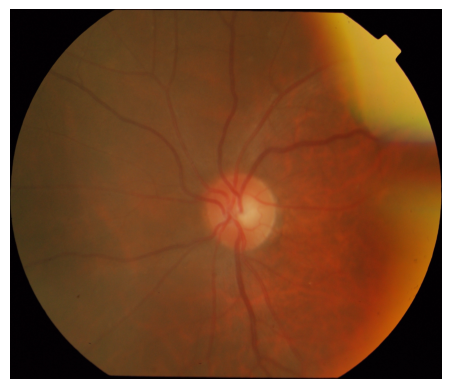

In [6]:
import matplotlib.pyplot as plt

plt.imshow(normal_img_training)
plt.axis(False)
plt.show()

In [7]:
img_training_disc=imageio.imread('/content/dataset_onh_segmentation/Training-20211018T055246Z-001/Training/GT/drishtiGS_008/SoftMap/drishtiGS_008_ODsegSoftmap.png')
img_training_cup=imageio.imread('/content/dataset_onh_segmentation/Training-20211018T055246Z-001/Training/GT/drishtiGS_008/SoftMap/drishtiGS_008_cupsegSoftmap.png')

img_training_disc.shape, img_training_cup.shape, type(img_training_disc), type(img_training_cup)

((1755, 2049), (1755, 2049), numpy.ndarray, numpy.ndarray)

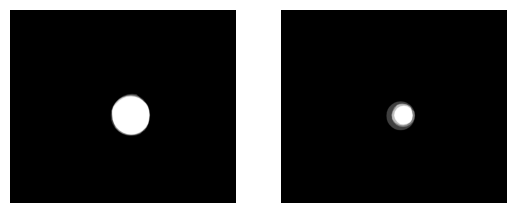

In [8]:
fig, axes= plt.subplots(1,2)
axes[0].imshow(img_training_disc, cmap='gray')
axes[0].axis(False)
axes[1].imshow(img_training_cup, cmap='gray')
axes[1].axis(False)
plt.show()

## 2. Masks from Average Boundary

In [9]:
import numpy as np

def boundary_to_np(file_path):

  boundary=[]

  with open(file_path, 'r', encoding='utf-8') as file:

    for coords in file:

      coords=coords.strip() # removes the \n per line now its : x y

      if not coords:
        continue # blank lines

      x,y=map(int,coords.split()) # [x,y]
      boundary.append([y,x])

  return np.array(boundary)

In [10]:
import cv2

def boundary_to_mask(img_path, file_path):

  img=cv2.imread(img_path)
  h,w,c=img.shape

  boundary=(boundary_to_np(file_path)).astype(np.int32) # boundary coords

  mask=np.zeros((h,w), dtype=np.int32) # h, w size ke [0]*(h,w)

  cv2.fillPoly(mask, [boundary], 255) # so fills white inside the boundary, rest is black (0)
  return mask

In [11]:
gt_path='/content/dataset_onh_segmentation/Training-20211018T055246Z-001/Training/GT'
glaucoma_images='/content/dataset_onh_segmentation/Training-20211018T055246Z-001/Training/Images/GLAUCOMA'
normal_images='/content/dataset_onh_segmentation/Training-20211018T055246Z-001/Training/Images/NORMAL'

In [12]:
img_paths=[] # Now, i need all images in one dir so i can map each t to corresponding avg boundary
# But its scattered across normal and glaucoma. so put everything in one image path folder and sort it.
count=0

for dir in [normal_images, glaucoma_images]:

  for img in os.listdir(dir):
    img_paths.append(os.path.join(dir,img)) # join parent folder and file path for sirect path to image in img_paths[]
    count+=1

count # 32+18

50

In [13]:
img_paths[:2]

['/content/dataset_onh_segmentation/Training-20211018T055246Z-001/Training/Images/NORMAL/drishtiGS_101.png',
 '/content/dataset_onh_segmentation/Training-20211018T055246Z-001/Training/Images/NORMAL/drishtiGS_036.png']

In [14]:
# /content/dataset_onh_segmentation/Training-20211018T055246Z-001/Training/GT/drishtiGS_002/AvgBoundary this is the path.
# So its /GT/ instead of Images/NORMAL/ or Images/GLAUCOMA/ and
# AvgBoundary/drishtiGS_002_CupAvgBoundary.txt OR
# AvgBoundary/drishtiGS_002_ODAvgBoundary.txt appended to path.

In [15]:
# So get the baseline path /content/dataset_onh_segmentation/Training-20211018T055246Z-001/Training/GT
# and append the image to it from img_paths. so remove the .png and add /AvgBoundary/ to all, then (img_name)_[CupAvgBoundary|ODAvgBoundary](.txt)

In [16]:
od_mask_dir=os.path.join('/content/dataset_onh_segmentation/Training-20211018T055246Z-001/Training','od_masks')
cup_mask_dir=os.path.join('/content/dataset_onh_segmentation/Training-20211018T055246Z-001/Training','cup_masks')

os.makedirs(od_mask_dir, exist_ok=True)
os.makedirs(cup_mask_dir, exist_ok=True)

In [17]:
count=0

for img in sorted(img_paths):
  # print(os.path.basename(img))
  img_name=os.path.basename(img) # ('drishtiGS_002', '.png')
  img_name=os.path.splitext(img_name)
  img_path=os.path.join(gt_path, img_name[0],'AvgBoundary')
  # print(img_path)

  od_path= os.path.join(img_path, img_name[0]+'_ODAvgBoundary.txt')
  cup_path= os.path.join(img_path, img_name[0]+'_CupAvgBoundary.txt')

  # if (img_name[0]=='drishtiGS_002'):
  #   with open(od_path, 'r') as f:
  #     print(f.readlines())

  # if (img_name[0]=='drishtiGS_002'):
  #   with open(cup_path, 'r') as f:
  #     print(f.readlines())


  od_mask=boundary_to_mask(img,od_path)
  cup_mask=boundary_to_mask(img,cup_path)

  # print(od_mask.shape, cup_mask.shape)

  cv2.imwrite(os.path.join(od_mask_dir, img_name[0]+'.png'), od_mask)
  cv2.imwrite(os.path.join(cup_mask_dir, img_name[0]+'.png'), cup_mask)
  count+=1

count

50

In [18]:
# so store it in new dir as dir_img_name.png

ref_path_img='/content/dataset_onh_segmentation/Training-20211018T055246Z-001/Training/Images/NORMAL/drishtiGS_008.png'
ref_path_mask_cup='/content/dataset_onh_segmentation/Training-20211018T055246Z-001/Training/cup_masks/drishtiGS_008.png'
ref_path_mask_od='/content/dataset_onh_segmentation/Training-20211018T055246Z-001/Training/od_masks/drishtiGS_008.png'

ref_img=imageio.imread(ref_path_img)
ref_mask_cup=imageio.imread(ref_path_mask_cup)
ref_mask_od=imageio.imread(ref_path_mask_od)

ref_img.shape[:2]==ref_mask_cup.shape==ref_mask_od.shape

True

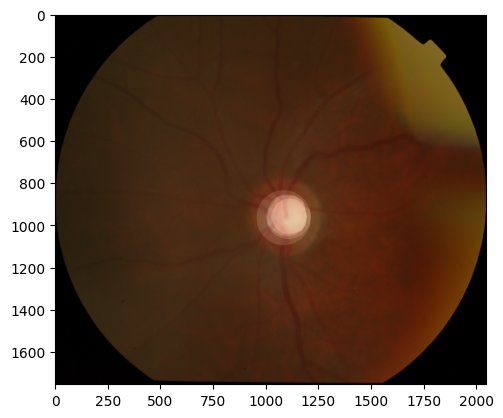

In [19]:

fig,axes=plt.subplots(1,1)

axes.imshow(ref_img)
axes.imshow(imageio.imread('/content/dataset_onh_segmentation/Training-20211018T055246Z-001/Training/GT/drishtiGS_008/SoftMap/drishtiGS_008_cupsegSoftmap.png'), alpha=0.4, cmap='gray')


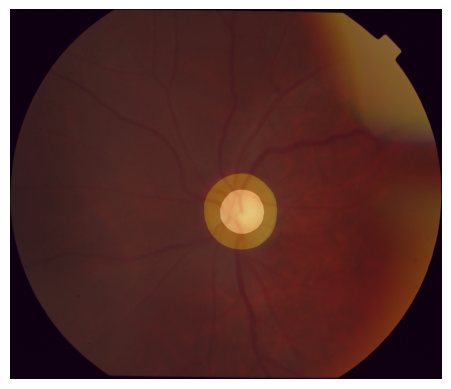

In [20]:
# ref_mask_cup=ref_mask_cup>0
# ref_mask_od=ref_mask_od>0 # masks for each

ref_mask_cup.shape, ref_mask_od.shape

fig,axes=plt.subplots(1,1)

axes.imshow(ref_img)
axes.imshow(ref_mask_cup, alpha=0.3, cmap='gray')
axes.imshow(ref_mask_od, alpha=0.2)
axes.axis(False)
plt.show()


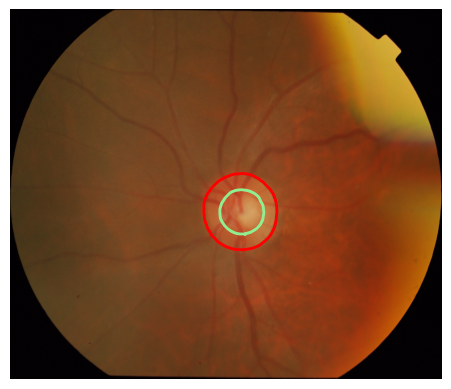

In [21]:
from skimage.measure import find_contours


fig,axes=plt.subplots(1,1)

for coords in find_contours(ref_mask_od, 0.5):
  axes.plot(coords[:,1], coords[:,0], color='red', linewidth=2) # (x,y)

for coords in find_contours(ref_mask_cup,0.5):
  axes.plot(coords[:,1], coords[:,0], linewidth=2, color='lightgreen')

axes.imshow(ref_img)


axes.axis(False)
plt.show()


## 3. Test Dataset Loading

In [22]:
gt_path='/content/dataset_onh_segmentation/Test-20211018T060000Z-001/Test/Test_GT'
glaucoma_images='/content/dataset_onh_segmentation/Test-20211018T060000Z-001/Test/Images/glaucoma'
normal_images='/content/dataset_onh_segmentation/Test-20211018T060000Z-001/Test/Images/normal'

In [23]:
img_paths_test=[] # Now, i need all images in one dir so i can map each t to corresponding avg boundary
# But its scattered across normal and glaucoma. so put everything in one image path folder and sort it.
count=0

for dir in [normal_images, glaucoma_images]:

  for img in os.listdir(dir):
    img_paths_test.append(os.path.join(dir,img)) # join parent folder and file path for sirect path to image in img_paths[]
    count+=1

count # 38+13

51

In [24]:
img_paths_test[:2]

['/content/dataset_onh_segmentation/Test-20211018T060000Z-001/Test/Images/normal/drishtiGS_099.png',
 '/content/dataset_onh_segmentation/Test-20211018T060000Z-001/Test/Images/normal/drishtiGS_072.png']

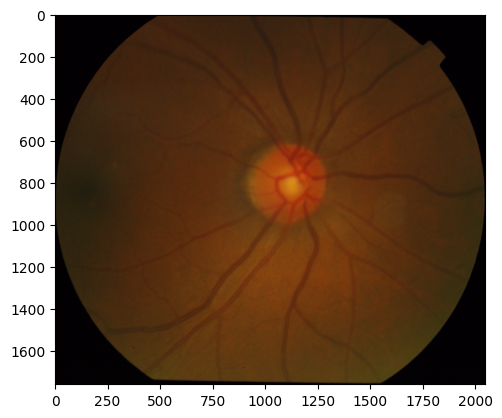

In [25]:
test_ref=imageio.imread('/content/dataset_onh_segmentation/Test-20211018T060000Z-001/Test/Images/normal/drishtiGS_072.png')
plt.imshow(test_ref)

In [26]:
cdr_mask_dir=os.path.join('/content/dataset_onh_segmentation/Test-20211018T060000Z-001/Test','cdr')

os.makedirs(cdr_mask_dir, exist_ok=True)

In [27]:
# count=0

# for img in sorted(img_paths):
#   # print(os.path.basename(img))
#   img_name=os.path.basename(img) # ('drishtiGS_002', '.png')
#   img_name=os.path.splitext(img_name)
#   img_path=os.path.join(gt_path, img_name[0],'AvgBoundary')
#   # print(img_path)

#   od_path= os.path.join(img_path, img_name[0]+'_ODAvgBoundary.txt')
#   cup_path= os.path.join(img_path, img_name[0]+'_CupAvgBoundary.txt')

#   if (img_name[0]=='drishtiGS_003'):
#     with open(od_path, 'r') as f:
#       print(f.readlines())

#   if (img_name[0]=='drishtiGS_003'):
#     with open(cup_path, 'r') as f:
#       print(f.readlines())
#   print(img_name[0])

#   # print(os.path.exists(img_path))
#   # print(os.path.exists(od_path))
#   # print(os.path.exists(cup_path))

#   if (img_name[0]=='drishtiGS_003'):
#     # od=imageio.imread(od_path)
#     # cup=imageio.imread(cup_path)
#     img=imageio.imread(img)

#     # plt.show(od)
#     # plt.show(cup)
#     plt.imshow(img)
#     plt.show()
#     break


#   # od_mask=boundary_to_mask(img,od_path)
#   # cup_mask=boundary_to_mask(img,cup_path)



#   # # print(od_mask.shape, cup_mask.shape)

#   # cv2.imwrite(os.path.join(od_mask_dir, img_name[0]+'.png'), od_mask)
#   # cv2.imwrite(os.path.join(cup_mask_dir, img_name[0]+'.png'), cup_mask)
#   # count+=1
#   # print(count)



In [28]:
# coords= boundary_to_np(od_path)
# coords.shape, len(np.unique(coords, axis=0)) -> ((1069156, 2), 725)

In [29]:
count=0
cdr_val={}

for img in sorted(img_paths_test):
  # print(os.path.basename(img))
  img_name=os.path.basename(img) # ('drishtiGS_002', '.png')
  img_name=os.path.splitext(img_name)
  img_path=os.path.join(gt_path, img_name[0],img_name[0] + '_cdrValues.txt')
  values=[]

  with open(img_path, 'r') as f:
    for line in f:
      if line.strip():
        for val in line.split():
          values.append(float(val))


  avg_cdr=np.mean(values)
  cdr_val[img_name[0]]=avg_cdr
  count+=1


  # # print(od_mask.shape, cup_mask.shape)

  # cv2.imwrite(os.path.join(od_mask_dir, img_name[0]+'.png'), od_mask)
  # cv2.imwrite(os.path.join(cup_mask_dir, img_name[0]+'.png'), cup_mask)
  # count+=1
  # print(count)

count

51

## 4. DataLoader for Image to Tensor

In [30]:
import torch

In [31]:
from torch.utils.data import Dataset, DataLoader

In [32]:
class Dataset_ONH_Segmentation(Dataset):
  def __init__(self, img_path, mask_path, size):
    self.img_path=img_path
    self.mask_path=mask_path
    self.size=size

  def __len__(self):
    return len(self.img_path)

  def __getitem__(self, idx):

    img_path=self.img_path[idx]
    img_name=os.path.splitext(os.path.basename(img_path))[0]

    img=cv2.imread(img_path)
    img=cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # cuz imageio uses bgr instead of rgb

    mask_name=os.path.join(self.mask_path, img_name+ '.png')
    mask=cv2.imread(mask_name, cv2.IMREAD_GRAYSCALE)

    img=cv2.resize(img, self.size, interpolation=cv2.INTER_LINEAR)
    mask=cv2.resize(mask, self.size, interpolation=cv2.INTER_NEAREST)


    # Now pytorch needs c h w not h w c and it needs to have pixel values from 0 - 1 not 0 - 255
    img=torch.tensor(img.transpose(2,0,1), dtype=torch.float32)/255

    # so mask needs to be booleen of maskwith c h w so 1, h , w
    mask=(mask>0).astype(np.float32)
    mask=torch.tensor(mask, dtype=torch.float32).unsqueeze(0) # unsqueeze to add color dimension

    return img, mask

In [33]:
train_dataset_od=Dataset_ONH_Segmentation(img_paths, od_mask_dir, (256,256))
train_dataset_cup=Dataset_ONH_Segmentation(img_paths, cup_mask_dir, (256,256))

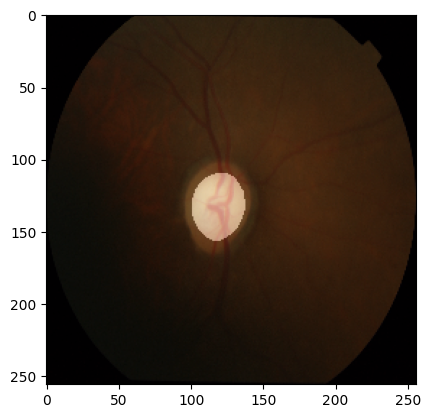

In [34]:
train_dataloader_cup=DataLoader(train_dataset_cup, batch_size=8, shuffle=True)
train_dataloader_od=DataLoader(train_dataset_od, batch_size=8, shuffle=True)

img, mask_cup=next(iter(train_dataloader_cup))
img=img[0]
mask_cup=mask_cup[0]
img.shape, mask_cup.shape

img_od,mask_od=next(iter(train_dataloader_od))
mask_od=mask_od[0]
img_od=img_od[0]

fig, axes=plt.subplots(1,1)
axes.imshow(img.permute(1,2,0))
axes.imshow(mask_cup.permute(1,2,0), alpha=0.4, cmap='gray')
plt.show()

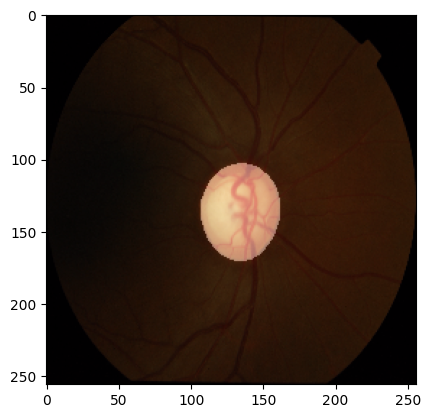

In [35]:
fig, axes=plt.subplots(1,1)
axes.imshow(img_od.permute(1,2,0))
axes.imshow(mask_od.permute(1,2,0), alpha=0.4, cmap='gray')
plt.show()

## 5. Loading Model : See Notes for UNet Explanation

In [36]:
! pip install segmentation_models_pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 8.1 MB/s eta 0:00:00


In [37]:
from segmentation_models_pytorch import Unet

model_cup=Unet(
    in_channels=3,
    classes=1,
    encoder_name='resnet34',
    encoder_weights='imagenet'
)

model_od=Unet(
    in_channels=3,
    classes=1,
    encoder_name='resnet34',
    encoder_weights='imagenet'
)

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 87.3MB            

model.safetensors: downloading bytes:           |  0.00B            

In [38]:
model_cup.state_dict, model_od.parameters()

(<bound method Module.state_dict of Unet(
   (encoder): ResNetEncoder(
     (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
     (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (relu): ReLU(inplace=True)
     (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
     (layer1): Sequential(
       (0): BasicBlock(
         (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
         (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
         (relu): ReLU(inplace=True)
         (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
         (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       )
       (1): BasicBlock(
         (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
         (bn1): BatchNo

## 6. Loss Function using IOU

In [39]:
# reference: https://www.youtube.com/watch?v=NqDBvUPD9jg

In [40]:
import torch.nn as nn

class IOU_Loss(nn.Module):
  def __init__(self, x= 1e-6):
    super().__init__()
    self.x=x # add so t+k-t*k !=0

  def forward(self, y_pred, y_true):

    y_pred=torch.sigmoid(y_pred) # converts into probabilityies

    t=y_pred.view(-1) # makes the (256,256) into (256*256,) long vector
    k=y_true.view(-1)

    intersection=(t*k).sum() # sum over the values
    iou= (intersection + self.x)/(t.sum()+k.sum() -intersection+self.x)

    return -iou

In [41]:
criterion = IOU_Loss()
optimizer_od= torch.optim.Adam(params=model_od.parameters(), lr=0.001)
optimizer_cup= torch.optim.Adam(params=model_cup.parameters(), lr=0.001)

In [42]:
device='cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

## 7. Training Loop

In [43]:
def train_model(model, dataloader, criterion, optimizer, device, epochs, task):

  model.to(device)

  for epoch in range(epochs):

    epoch_loss=0

    for (img,mask) in dataloader:

      model.train()
      optimizer.zero_grad()

      img=img.to(device)
      mask=mask.to(device)

      y_pred=model(img)

      loss=criterion(y_pred, mask)

      loss.backward()
      optimizer.step()

      epoch_loss+=loss.item()

    epoch_loss/=len(dataloader)

    print(f"Task: {task}, Epoch: {epoch+1}, Training Loss: {epoch_loss: .3f}")


In [44]:
train_model(model_od, train_dataloader_od, criterion, optimizer_od, device, 40, 'Optical Disk Segmentation')

Task: Optical Disk Segmentation, Epoch: 1, Training Loss: -0.069
Task: Optical Disk Segmentation, Epoch: 2, Training Loss: -0.136
Task: Optical Disk Segmentation, Epoch: 3, Training Loss: -0.217
Task: Optical Disk Segmentation, Epoch: 4, Training Loss: -0.308
Task: Optical Disk Segmentation, Epoch: 5, Training Loss: -0.460
Task: Optical Disk Segmentation, Epoch: 6, Training Loss: -0.600
Task: Optical Disk Segmentation, Epoch: 7, Training Loss: -0.712
Task: Optical Disk Segmentation, Epoch: 8, Training Loss: -0.799
Task: Optical Disk Segmentation, Epoch: 9, Training Loss: -0.842
Task: Optical Disk Segmentation, Epoch: 10, Training Loss: -0.891
Task: Optical Disk Segmentation, Epoch: 11, Training Loss: -0.900
Task: Optical Disk Segmentation, Epoch: 12, Training Loss: -0.923
Task: Optical Disk Segmentation, Epoch: 13, Training Loss: -0.929
Task: Optical Disk Segmentation, Epoch: 14, Training Loss: -0.934
Task: Optical Disk Segmentation, Epoch: 15, Training Loss: -0.932
Task: Optical Disk 

In [45]:
train_model(model_cup, train_dataloader_cup, criterion, optimizer_cup, device, 40, 'Cup Segmentation')

Task: Cup Segmentation, Epoch: 1, Training Loss: -0.032
Task: Cup Segmentation, Epoch: 2, Training Loss: -0.055
Task: Cup Segmentation, Epoch: 3, Training Loss: -0.087
Task: Cup Segmentation, Epoch: 4, Training Loss: -0.123
Task: Cup Segmentation, Epoch: 5, Training Loss: -0.179
Task: Cup Segmentation, Epoch: 6, Training Loss: -0.285
Task: Cup Segmentation, Epoch: 7, Training Loss: -0.373
Task: Cup Segmentation, Epoch: 8, Training Loss: -0.505
Task: Cup Segmentation, Epoch: 9, Training Loss: -0.630
Task: Cup Segmentation, Epoch: 10, Training Loss: -0.701
Task: Cup Segmentation, Epoch: 11, Training Loss: -0.751
Task: Cup Segmentation, Epoch: 12, Training Loss: -0.760
Task: Cup Segmentation, Epoch: 13, Training Loss: -0.830
Task: Cup Segmentation, Epoch: 14, Training Loss: -0.845
Task: Cup Segmentation, Epoch: 15, Training Loss: -0.840
Task: Cup Segmentation, Epoch: 16, Training Loss: -0.860
Task: Cup Segmentation, Epoch: 17, Training Loss: -0.864
Task: Cup Segmentation, Epoch: 18, Train

## 8. Testing Model

In [46]:
class Test_Dataset(Dataset):
  def __init__(self,img_paths, cdr_val, size):
    self.cdr_val=cdr_val
    self.img_paths=img_paths
    self.size=size

  def __len__(self):
    return len(self.img_paths)

  def __getitem__(self,idx):

    img_path=self.img_paths[idx]
    img_name=os.path.splitext(os.path.basename(img_path))[0]

    img=cv2.imread(img_path)
    img=cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img=cv2.resize(img, self.size, interpolation=cv2.INTER_LINEAR)
    img=torch.tensor(img.transpose(2,0,1), dtype=torch.float32)/255

    cdr_value=self.cdr_val[img_name]

    return img, cdr_value,img_name

In [47]:
test_dataset=Test_Dataset(img_paths_test, cdr_val,(256,256))
test_dataloader=DataLoader(test_dataset, batch_size=1, shuffle=False)

next(iter(test_dataloader))

[tensor([[[[0.0118, 0.0078, 0.0118,  ..., 0.0078, 0.0118, 0.0078],
           [0.0118, 0.0118, 0.0118,  ..., 0.0118, 0.0078, 0.0118],
           [0.0157, 0.0235, 0.0078,  ..., 0.0118, 0.0078, 0.0078],
           ...,
           [0.0157, 0.0118, 0.0196,  ..., 0.0157, 0.0157, 0.0078],
           [0.0157, 0.0118, 0.0196,  ..., 0.0118, 0.0157, 0.0118],
           [0.0078, 0.0275, 0.0196,  ..., 0.0118, 0.0118, 0.0078]],
 
          [[0.0039, 0.0000, 0.0039,  ..., 0.0000, 0.0039, 0.0000],
           [0.0039, 0.0000, 0.0039,  ..., 0.0000, 0.0000, 0.0039],
           [0.0039, 0.0039, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           ...,
           [0.0039, 0.0039, 0.0078,  ..., 0.0039, 0.0078, 0.0039],
           [0.0039, 0.0039, 0.0078,  ..., 0.0039, 0.0039, 0.0039],
           [0.0000, 0.0039, 0.0078,  ..., 0.0039, 0.0000, 0.0118]],
 
          [[0.0118, 0.0078, 0.0118,  ..., 0.0078, 0.0118, 0.0078],
           [0.0118, 0.0078, 0.0118,  ..., 0.0078, 0.0078, 0.0118],
           [0.0118, 0.01

In [48]:
model_cup.eval()
model_od.eval()

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

In [49]:
from scipy import ndimage as ndi

def largest_connected_component(mask):

    label,num = ndi.label(mask)

    if num==0:
      return mask

    sizes=ndi.sum(mask, label, range(1,num+1)) # pixels per section
    largest_connected=np.argmax(sizes)+1

    return (label==largest_connected).astype(np.float32) # so gives true for largest label, else false

In [50]:
cdr_pred=[]
img_name_list=[]
cdr_true=[]

In [51]:
with torch.inference_mode():

  for img, cdr, img_name in test_dataloader:

    img=img.to(device)

    pred_od=model_od(img)
    pred_cup=model_cup(img)

    pred_od=torch.sigmoid(pred_od)
    pred_cup=torch.sigmoid(pred_cup)

    # now u need probabilities > 0.5 as 1 , the rest as 0. (ouside disk, probability close to 0, inside disk, close to 1). float() so 1.0 and 0.0 not True and False.

    pred_od_mask=(pred_od>0.5).float()
    pred_cup_mask=(pred_cup>0.5).float()

    # Now pred od if pred cpu are in 1 1 256 256 -> 256 256

    pred_od_mask=pred_od_mask.squeeze()
    pred_cup_mask=pred_cup_mask.squeeze()

    # ow  need np.where but cant use it on cude

    pred_od_mask=pred_od_mask.cpu().numpy()
    pred_cup_mask=pred_cup_mask.cpu().numpy()

    pred_od_mask=largest_connected_component(pred_od_mask)
    pred_cup_mask=largest_connected_component(pred_cup_mask)

    od_rows=np.where(pred_od_mask>0)[0] #(returns row col where u have pred_od_mask as 1), so only need rows
    cup_rows=np.where(pred_cup_mask>0)[0]

    if(len(od_rows)==0 or len(cup_rows)==0):
      pred_cdr=0

    else:

      od_diameter=od_rows.max()-od_rows.min()
      cup_diameter=cup_rows.max()-cup_rows.min()

      pred_cdr=cup_diameter/od_diameter

    cdr_true.append(cdr.item())

    cdr_pred.append(pred_cdr)
    img_name_list.append(img_name[0])


In [52]:
len(cdr_pred), len(cdr_true), cdr_pred[:10], cdr_true[:10]

(51,
 51,
 [np.float64(0.6885245901639344),
  np.float64(0.6274509803921569),
  np.float64(0.6730769230769231),
  np.float64(0.21052631578947367),
  np.float64(0.6885245901639344),
  np.float64(0.7894736842105263),
  np.float64(0.6981132075471698),
  np.float64(0.7333333333333333),
  np.float64(0.4897959183673469),
  np.float64(0.48936170212765956)],
 [0.595,
  0.5625,
  0.5050000000000001,
  0.3225,
  0.52,
  0.7525000000000001,
  0.625,
  0.7525,
  0.4425,
  0.3925])

## 9. Output Analysis

In [53]:
from sklearn.metrics import mean_absolute_error

mae=mean_absolute_error(cdr_true, cdr_pred)
mae

0.0628445603191908

In [54]:
from sklearn.metrics import mean_squared_error

rmse=np.sqrt(mean_squared_error(cdr_true, cdr_pred))
rmse

np.float64(0.07758213130381006)

In [55]:
threshold=0.5

In [56]:
true_labels=[]

for val in cdr_true:

  if(val>=threshold):
    true_labels.append(1)
  else:
    true_labels.append(0)

In [57]:
pred_labels=[]

for val in cdr_pred:

  if(val>=threshold):
    pred_labels.append(1)
  else:
    pred_labels.append(0)

In [58]:
len(pred_labels),len(true_labels)

(51, 51)

In [59]:
sum=0

for i in range(51):
  print(pred_labels[i]==true_labels[i])
  sum+=float((pred_labels[i]==true_labels[i]))

print((sum/len(pred_labels))*100)

True
True
True
True
True
True
True
True
True
True
False
True
True
True
True
True
True
True
True
True
True
False
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
False
True
True
True
94.11764705882352


In [60]:
from sklearn.metrics import accuracy_score

acc=accuracy_score(true_labels, pred_labels)

print(f"Accuracy: {acc*100:.4f}%")

Accuracy: 94.1176%


In [61]:
from sklearn.metrics import confusion_matrix

cm=confusion_matrix(true_labels, pred_labels)

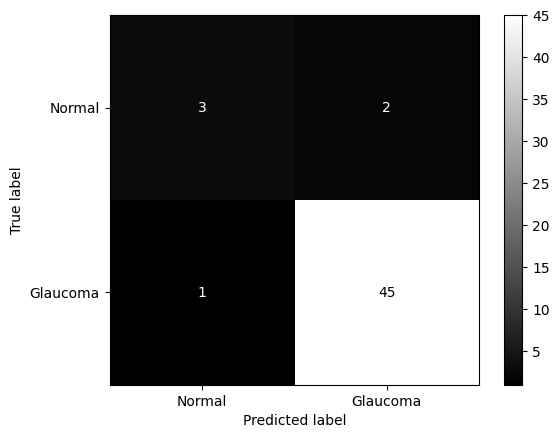

In [62]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Glaucoma']).plot(cmap='gray')
plt.show()

In [63]:
from sklearn.metrics import classification_report

print(classification_report(true_labels, pred_labels, target_names=['Normal', 'Glaucoma']))

              precision    recall  f1-score   support

      Normal       0.75      0.60      0.67         5
    Glaucoma       0.96      0.98      0.97        46

    accuracy                           0.94        51
   macro avg       0.85      0.79      0.82        51
weighted avg       0.94      0.94      0.94        51



In [64]:
torch.save(model_od.state_dict(), 'model_od.pth')
torch.save(model_cup.state_dict(), 'model_cup.pth')

In [65]:
from google.colab import files
files.download('model_od.pth')
files.download('model_cup.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [66]:
image_plot=img.squeeze().cpu().permute(1,2,0)
image_plot=image_plot.numpy()
image_plot.shape

(256, 256, 3)

In [67]:
od_mask_plot=pred_od_mask.squeeze()
cup_mask_plot=pred_cup_mask.squeeze()

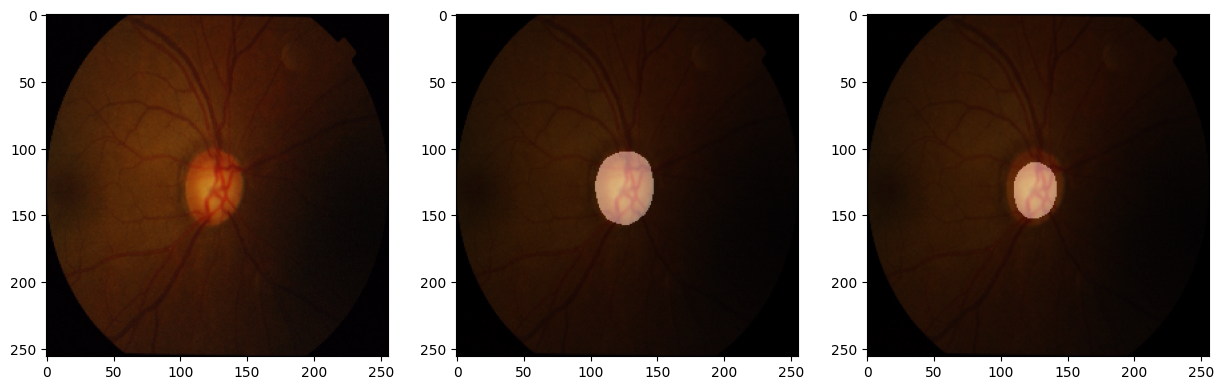

In [68]:
fig, axis=plt.subplots(1,3, figsize=(15,15))

axis[0].imshow(image_plot)
axis[1].imshow(image_plot)
axis[1].imshow(od_mask_plot, alpha=0.4, cmap='gray')
axis[2].imshow(image_plot)
axis[2].imshow(cup_mask_plot, alpha=0.4, cmap='gray')

plt.show()